In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,
    n_features=3,
    centers=2,
    cluster_std=4,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["x1", "x2", "x3"]
)

df["target"] = y

print(f"{df.head()}\n")
print(f"shape: {df.shape}\n")
print(df["target"].value_counts())

         x1         x2         x3  target
0  0.114700  -6.074989  -5.746958       1
1  6.003224  -9.618146  -3.717607       1
2 -0.682185  11.293355   6.430713       0
3 -1.295185  -4.242645  -3.129829       1
4  1.705370   5.216691  15.169407       0

shape: (1000, 4)

target
1    500
0    500
Name: count, dtype: int64


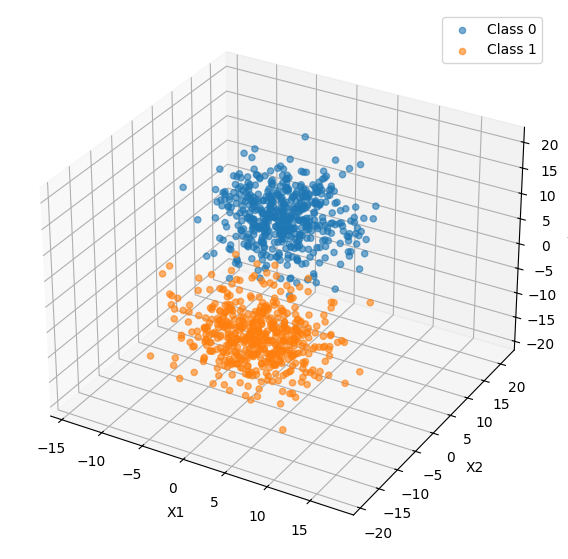

In [131]:
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df.loc[df["target"] == 0, "x1"],
    df.loc[df["target"] == 0, "x2"],
    df.loc[df["target"] == 0, "x3"],
    alpha=0.6,
    label="Class 0"
)

ax.scatter(
    df.loc[df["target"] == 1, "x1"],
    df.loc[df["target"] == 1, "x2"],
    df.loc[df["target"] == 1, "x3"],
    alpha=0.6,
    label="Class 1"
)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

ax.legend()

plt.show()

In [132]:
class PCA():
    def __init__(self, n_component):
        self.n_component = n_component
        self.mean = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.V = None

    def centered(self, X):
        return X - self.mean

    def cov(self, X_centered):
        n = len(X_centered)
        return (X_centered.T @ X_centered) / (n - 1)

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = self.centered(X)
        cov_matrix = self.cov(X_centered)
        self.eigenvalues, self.eigenvectors = np.linalg.eig(cov_matrix)
        idx = np.argsort(self.eigenvalues)[::-1]
        self.eigenvalues = self.eigenvalues[idx]
        self.eigenvectors = self.eigenvectors[:, idx]
        self.V = self.eigenvectors[:, :self.n_component]

    def transform(self, X):
        X_centered = self.centered(X)

        return X_centered @ self.V

(1000, 2)


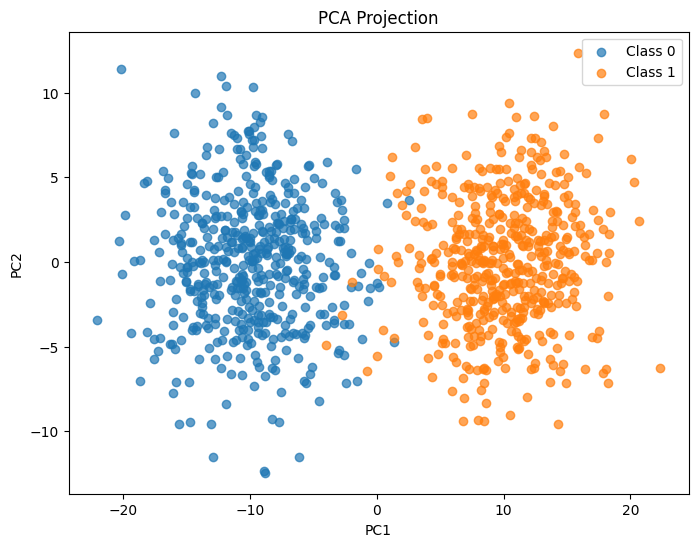

In [133]:
pca = PCA(n_component=2)
pca.fit(X)
X_pca = pca.transform(X)
print(X_pca.shape)

plt.figure(figsize=(8, 6))
mask0 = y == 0
mask1 = y == 1

plt.scatter(
    X_pca[mask0, 0],
    X_pca[mask0, 1],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    X_pca[mask1, 0],
    X_pca[mask1, 1],
    label="Class 1",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")

plt.legend()

plt.show()